In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from functools import reduce #for counting iterations
import pandas as pd

In [2]:
#list
random_seeds = [12,24,32,42,58,12_1]
accuracies = [0.97826087,0.98136646,0.987654321,0.981481481,0.965838509,0.975308642]


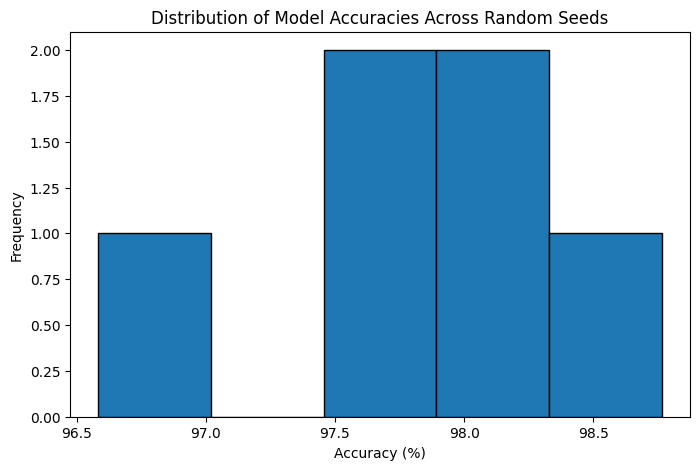

In [3]:
# Convert accuracy to percentage
accuracies_percent = [acc * 100 for acc in accuracies]
#histogram plot
plt.figure(figsize=(8, 5))

plt.hist(
    accuracies_percent,
    bins=5,
    edgecolor='black'
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Model Accuracies Across Random Seeds")

plt.show()

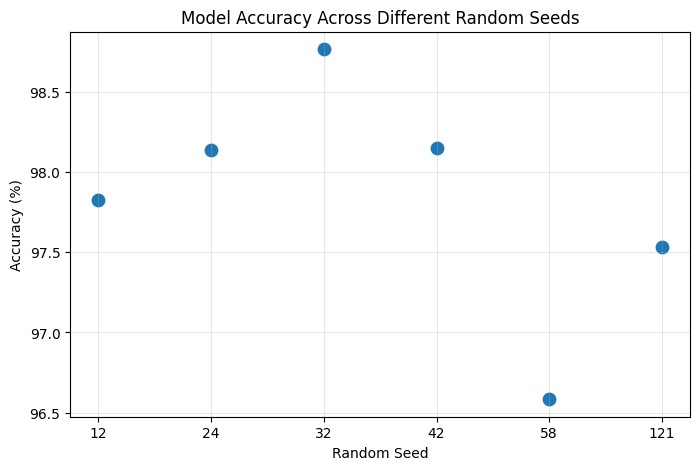

In [4]:
#scatter plot accuracy vs seeds

#random_seeds = [12, 24, 32, 42, 58, 12_1]
#accuracies = [0.97826087, 0.98136646, 0.987654321, 0.981481481, 0.965838509, 0.975308642]

#accuracies_percent = [acc * 100 for acc in accuracies]

plt.figure(figsize=(8, 5))

plt.scatter(range(len(random_seeds)), accuracies_percent, s=80)

plt.xticks(range(len(random_seeds)), random_seeds)
plt.xlabel("Random Seed")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Across Different Random Seeds")

plt.grid(True, alpha=0.3)
plt.show()

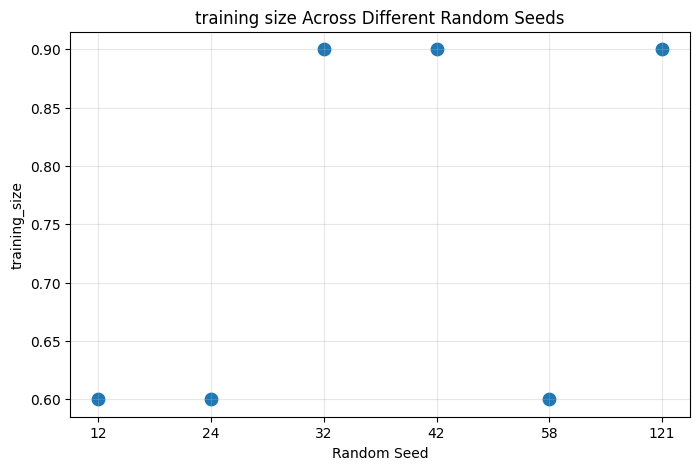

In [5]:
#scatter plot, training vs seeds

random_seeds = [12, 24, 32, 42, 58, 12_1]
training_size = [0.6, 0.6, 0.9, 0.9, 0.6, 0.9]

training_size_percent = [training_size * 100 for acc in accuracies]

plt.figure(figsize=(8, 5))

plt.scatter(range(len(random_seeds)), training_size, s=80)

plt.xticks(range(len(random_seeds)), random_seeds)
plt.xlabel("Random Seed")
plt.ylabel("training_size")
plt.title("training size Across Different Random Seeds")

plt.grid(True, alpha=0.3)
plt.show()

In [6]:
#output files for best models
files = {
    "RS_12": "best_model_prediction_cv_candidates_above_0.9_RS_12.csv",
    "RS_24": "best_model_prediction_cv_candidates_above_0.9_RS_24.csv",
    "RS_32": "best_model_prediction_cv_candidates_above_0.9_RS_36.csv",
    "RS_42": "best_model_prediction_cv_candidates_above_0.9_RS_42.csv",
    "RS_58": "best_model_prediction_cv_candidates_above_0.9_RS_58.csv",
    "RS_12_1": "best_model_prediction_cv_candidates_above_0.9_RS_12_1.csv"
}

# Read each CSV
dfs = {}

for name, file in files.items():
    df = pd.read_csv(file)
    
    # Keep objectId and CV probability
   
    df = df[["objectId", "cv_probability"]].copy()
    
    # Rename probability column according to random seed
    df = df.rename(columns={
        "cv_probability": f"CV_probability_{name}"
    })
    
    dfs[name] = df


# Merge all files using OUTER JOIN
# This keeps every unique objectId
merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="objectId",
        how="outer"
    ),
    dfs.values()
)



# Find how many files each object appears in


probability_columns = [
    col for col in merged_df.columns
    if col.startswith("CV_probability_")
]

merged_df["number_of_files"] = (
    merged_df[probability_columns]
    .notna()
    .sum(axis=1)
)



# Create a column showing which files contain each object

def find_common_files(row):
    common_files = []
    
    for name in files.keys():
        column = f"CV_probability_{name}"
        
        if pd.notna(row[column]):
            common_files.append(name)
    
    return ", ".join(common_files)


merged_df["common_in_files"] = merged_df.apply(
    find_common_files,
    axis=1
)



# Sort by number of files
# 6 files first, then 5, 4, 3, 2, 1


merged_df = merged_df.sort_values(
    by="number_of_files",
    ascending=False
)



# Keep only objects common to at least 2 files


common_objects = merged_df[
    merged_df["number_of_files"] >= 2
].copy()


# Save the result


common_objects.to_csv(
    "common_MCV_candidates_2_to_6_files_best_model.csv",
    index=False
)


print(
    f"Total objects common to at least 2 files: "
    f"{len(common_objects)}"
)

#print(
 #   common_objects[
  #      ["objectId", "number_of_files", "common_in_files"]
  #  ].head(20)
#)

Total objects common to at least 2 files: 424


In [7]:
df=pd.read_csv("common_MCV_candidates_2_to_6_files_best_model.csv")

In [8]:
df

,objectId,CV_probability_RS_12,CV_probability_RS_24,CV_probability_RS_32,CV_probability_RS_42,CV_probability_RS_58,CV_probability_RS_12_1,number_of_files,common_in_files
0,ZTF17aaaadkj,0.930266,0.923465,0.950426,0.987242,0.975702,0.918291,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
1,ZTF18acppfsr,0.957662,0.952212,0.928486,0.929306,0.923075,0.900294,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
2,ZTF18acukars,0.992995,0.971764,0.964902,0.992092,0.996430,0.963192,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
3,ZTF18acumsif,0.988247,0.944283,0.925089,0.965498,0.967720,0.927909,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
4,ZTF18acuxpxi,0.997991,0.977523,0.966246,0.995046,0.995710,0.960146,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
...,...,...,...,...,...,...,...,...,...
419,ZTF18aabsiul,NaN,NaN,NaN,0.904718,NaN,0.900530,2,"RS_42, RS_12_1"
420,ZTF18aahkfwx,0.935795,0.909449,NaN,NaN,NaN,NaN,2,"RS_12, RS_24"
421,ZTF18aatczka,0.972745,NaN,NaN,NaN,0.931166,NaN,2,"RS_12, RS_58"
422,ZTF17aadhktq,0.960321,0.918127,NaN,NaN,NaN,NaN,2,"RS_12, RS_24"


In [10]:
#output files for previously saved models
files = {
    "RS_12": "cv_candidates_above_0.9_for_previously_saved_model_RS_12.csv",
    "RS_24": "cv_candidates_above_0.9_for_previously_saved_model_RS_24.csv",
    "RS_32": "cv_candidates_above_0.9_for_previously_saved_model_RS_36.csv",
    "RS_42": "cv_candidates_above_0.9_for_previously_saved_model_RS_42.csv",
    "RS_58": "cv_candidates_above_0.9_for_previously_saved_model_RS_58.csv",
    "RS_12_1": "cv_candidates_above_0.9_for_previously_saved_model_RS_12_1.csv"
}

# Read each CSV
dfs = {}

for name, file in files.items():
    df = pd.read_csv(file)
    
    # Keep objectId and CV probability
   
    df = df[["objectId", "cv_probability"]].copy()
    
    # Rename probability column according to random seed
    df = df.rename(columns={
        "cv_probability": f"CV_probability_{name}"
    })
    
    dfs[name] = df


# Merge all files using OUTER JOIN
# This keeps every unique objectId
merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="objectId",
        how="outer"
    ),
    dfs.values()
)



# Find how many files each object appears in


probability_columns = [
    col for col in merged_df.columns
    if col.startswith("CV_probability_")
]

merged_df["number_of_files"] = (
    merged_df[probability_columns]
    .notna()
    .sum(axis=1)
)



# Create a column showing which files contain each object

def find_common_files(row):
    common_files = []
    
    for name in files.keys():
        column = f"CV_probability_{name}"
        
        if pd.notna(row[column]):
            common_files.append(name)
    
    return ", ".join(common_files)


merged_df["common_in_files"] = merged_df.apply(
    find_common_files,
    axis=1
)



# Sort by number of files
# 6 files first, then 5, 4, 3, 2, 1


merged_df = merged_df.sort_values(
    by="number_of_files",
    ascending=False
)



# Keep only objects common to at least 2 files


common_objects = merged_df[
    merged_df["number_of_files"] >= 2
].copy()


# Save the result


common_objects.to_csv(
    "common_MCV_candidates_2_to_6_files_for_previously_saved_model.csv",
    index=False
)


print(
    f"Total objects common to at least 2 files: "
    f"{len(common_objects)}"
)

#print(
 #   common_objects[
  #      ["objectId", "number_of_files", "common_in_files"]
  #  ].head(20)
#)

Total objects common to at least 2 files: 328


In [11]:
df_model=pd.read_csv("common_MCV_candidates_2_to_6_files_for_previously_saved_model.csv")
df_model

,objectId,CV_probability_RS_12,CV_probability_RS_24,CV_probability_RS_32,CV_probability_RS_42,CV_probability_RS_58,CV_probability_RS_12_1,number_of_files,common_in_files
0,ZTF19aaacbdv,0.953475,0.953115,0.956726,0.939609,0.939423,0.938869,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
1,ZTF18aceljyy,0.969036,0.967920,0.972320,0.971410,0.949834,0.941016,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
2,ZTF19aagmvuk,0.962802,0.945979,0.960719,0.930443,0.913105,0.919195,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
3,ZTF18aakbyuy,0.970911,0.972063,0.959818,0.984221,0.964118,0.978160,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
4,ZTF18acyutkw,0.972565,0.959360,0.966863,0.954248,0.939190,0.959426,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
...,...,...,...,...,...,...,...,...,...
323,ZTF18adaiwkf,0.963920,NaN,0.911149,NaN,NaN,NaN,2,"RS_12, RS_32"
324,ZTF22abinukn,NaN,NaN,NaN,0.907910,NaN,0.944006,2,"RS_42, RS_12_1"
325,ZTF25abuhmys,NaN,0.904931,NaN,NaN,NaN,0.901531,2,"RS_24, RS_12_1"
326,ZTF18abtnfzy,0.921154,NaN,NaN,0.915897,NaN,NaN,2,"RS_12, RS_42"


In [13]:
df_model

,objectId,CV_probability_RS_12,CV_probability_RS_24,CV_probability_RS_32,CV_probability_RS_42,CV_probability_RS_58,CV_probability_RS_12_1,number_of_files,common_in_files,mean_probability
12,ZTF18acuxpxi,0.991223,0.989077,0.979449,0.988042,0.984518,0.983716,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1",0.986004
62,ZTF20adbxgzv,0.983082,0.986517,0.977317,0.990437,0.976448,0.984645,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1",0.983074
13,ZTF18acukars,0.983695,0.986004,0.985943,0.970792,0.973553,0.984313,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1",0.980717
25,ZTF18adjcgck,0.988915,0.982769,0.973810,0.977631,0.971761,0.977346,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1",0.978706
53,ZTF24abyucsd,0.970012,0.982419,0.978794,0.987005,0.945201,0.978606,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1",0.973673
...,...,...,...,...,...,...,...,...,...,...
282,ZTF19aakuyyr,NaN,NaN,0.902450,NaN,0.911608,NaN,2,"RS_32, RS_58",0.907029
297,ZTF18acvwabh,0.909050,NaN,0.902971,NaN,NaN,NaN,2,"RS_12, RS_32",0.906011
317,ZTF20aaqberk,NaN,0.904666,NaN,0.906768,NaN,NaN,2,"RS_24, RS_42",0.905717
284,ZTF17aadrnho,NaN,NaN,NaN,NaN,0.909006,0.901313,2,"RS_58, RS_12_1",0.905159
